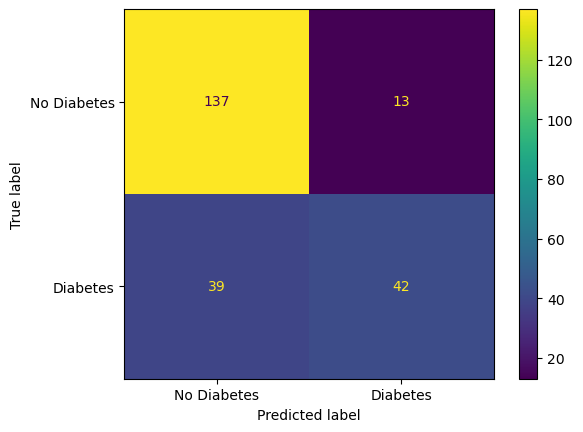

              precision    recall  f1-score   support

           0       0.78      0.91      0.84       150
           1       0.76      0.52      0.62        81

    accuracy                           0.77       231
   macro avg       0.77      0.72      0.73       231
weighted avg       0.77      0.77      0.76       231



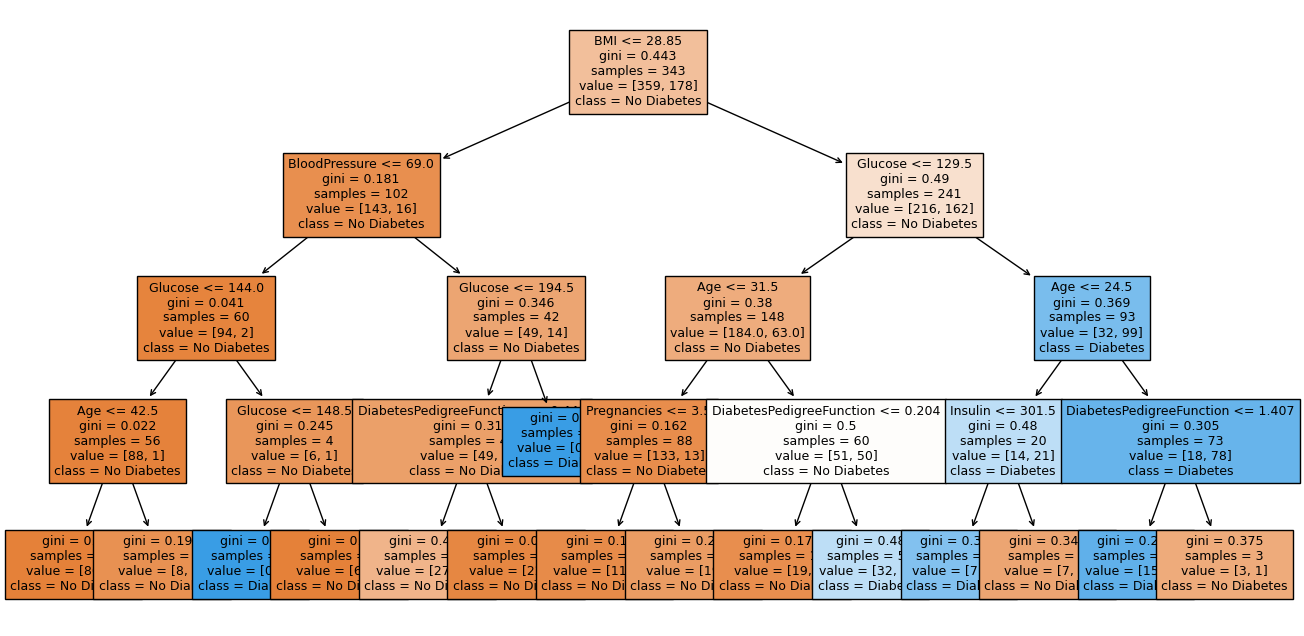

In [7]:
#Random Forest -  Diabetes

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("diabetes.csv")

x = df.drop("Outcome",axis=1)
y = df["Outcome"]

x_train,x_test,y_train,y_test = train_test_split(
    x,y,test_size=0.3,random_state=101
)

model = RandomForestClassifier(n_estimators=100,max_depth=4,random_state=42)

model.fit(x_train,y_train)

y_pred = model.predict(x_test)

cm = confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm,display_labels=["No Diabetes","Diabetes"]).plot()
plt.show()

print(classification_report(y_test,y_pred))

#Visualize one tree from the forest
plt.figure(figsize=(16,8))
plot_tree(model.estimators_[0],feature_names=x.columns,class_names=["No Diabetes","Diabetes"],filled=True,fontsize=9)
plt.show()

